# CIGALE mock photometry fit with JAX-CIGALE + Cue

This notebook is an audit notebook for one controlled photometric validation.

**Generator**: CIGALE `sfhdelayed -> bc03 -> nebular -> dustatt_modified_starburst`.

**Fitter**: experimental `sedinfer.experimental.jaxcigale` graph with DSPS stellar emission, Cue nebular emission, modified starburst attenuation, IGM, redshifting, and NumPyro NUTS.

The sampled NUTS coordinate uses `tage_fraction = tage_gyr / age_universe(z)` so proposals cannot exceed the age of the Universe. All reported tables and plots convert it back to the physical quantity `tage_gyr`.

The default cells are safe: they load existing outputs if available. The long-running CIGALE/JAX stages are controlled by boolean flags in the next cell.

## Scientific data flow

1. A CIGALE rest-frame SED is generated per solar mass formed.
2. CIGALE luminosity units are converted from `W / nm` to `Lsun / Angstrom`.
3. The SED is multiplied once by `10**log10_mass`.
4. It is redshifted to `z = 0.2` and integrated through simple UV + ugriz + YJH Gaussian filters.
5. Noise is added in maggies with `sigma = relative_error * abs(flux) + noise_floor`.
6. JAX-CIGALE predicts model maggies for each NUTS proposal.
7. The likelihood is diagonal Gaussian in the active photometric bands.
8. NUTS samples the posterior in internal coordinates, but the notebook reports physical coordinates.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/Users/gregoire/Documents/Sedfitting/sedinfer-public')
EXAMPLE_SCRIPT = REPO_ROOT / 'examples' / 'experimental_cigale_mock_jaxcigale_cue_nuts.py'

# This folder contains a cheap freshly regenerated CIGALE mock with the current
# tage_fraction internal coordinate. The fit may or may not exist yet.
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'experimental_cigale_mock_jaxcigale_cue_nuts_sfhfrac_10pct_reported'

CIGALE_PYTHON = Path('/Users/gregoire/opt/anaconda3/envs/sbi_candide/bin/python')
JAX_PYTHON = Path('/Users/gregoire/miniforge3/envs/dsps_nuts/bin/python')
CIGALE_SOURCE = Path('/Users/gregoire/Work/cigale-v2022.0')

RUN_CIGALE_MOCK = False
RUN_JAX_FIT = False
RUN_PLOTS = False

MOCK_FILE = OUTPUT_DIR / 'cigale_bc03_nebular_dust_mock.npz'
FIT_FILE = OUTPUT_DIR / 'jaxcigale_cue_nuts_fit.npz'
SUMMARY_FILE = OUTPUT_DIR / 'jaxcigale_cue_nuts_summary.json'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Mock exists:', MOCK_FILE.exists())
print('Fit exists:', FIT_FILE.exists())

Repository: /Users/gregoire/Documents/Sedfitting/sedinfer-public
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/experimental_cigale_mock_jaxcigale_cue_nuts_sfhfrac_10pct_reported
Mock exists: True
Fit exists: True


In [2]:
def run_stage(stage: str, *, python: Path, extra_env: dict[str, str] | None = None, extra_args: list[str] | None = None):
    env = os.environ.copy()
    env['MPLCONFIGDIR'] = '/private/tmp/mplconfig-sedinfer'
    env['PYTHONPATH'] = str(REPO_ROOT)
    if extra_env:
        env.update(extra_env)
    command = [
        str(python),
        str(EXAMPLE_SCRIPT),
        '--stage', stage,
        '--output-dir', str(OUTPUT_DIR),
    ]
    if extra_args:
        command.extend(extra_args)
    print('Running:', ' '.join(command))
    subprocess.run(command, cwd=REPO_ROOT, env=env, check=True)

if RUN_CIGALE_MOCK:
    run_stage(
        'mock',
        python=CIGALE_PYTHON,
        extra_env={'PYTHONPATH': f'{REPO_ROOT}:{CIGALE_SOURCE}'},
        extra_args=['--relative-error', '0.10', '--noise-floor', '1e-13', '--seed', '1207'],
    )

if RUN_JAX_FIT:
    run_stage(
        'fit',
        python=JAX_PYTHON,
        extra_args=[
            '--warmup', '150',
            '--samples', '250',
            '--precision', 'float64',
            '--nuts-target-accept', '0.75',
            '--nuts-max-tree-depth', '8',
            '--nuts-dense-mass',
            '--no-progress',
        ],
    )

if RUN_PLOTS:
    run_stage('plots', python=JAX_PYTHON)

## Load mock data and provenance

This cell fails loudly if the mock file is absent. If that happens, set `RUN_CIGALE_MOCK = True` above and rerun the stage cell in an environment where CIGALE is available.

In [3]:
if not MOCK_FILE.exists():
    raise FileNotFoundError(f'Missing mock file: {MOCK_FILE}')

mock = np.load(MOCK_FILE, allow_pickle=True)
truth_json = json.loads((OUTPUT_DIR / 'cigale_mock_truth.json').read_text())

band_names = [str(x) for x in mock['filter_names']]
centers_a = mock['filter_centers_a']
noiseless = mock['noiseless_flux_maggies']
observed = mock['observed_flux_maggies']
sigma = mock['sigma_maggies']

truth_report_names = [str(x) for x in mock.get('true_theta_reported_names', mock['true_theta_names'])]
truth_report = np.asarray(mock.get('true_theta_reported', mock['true_theta_for_fit']), dtype=float)
truth_table = pd.DataFrame({'parameter': truth_report_names, 'truth': truth_report})

print('Generator:', truth_json['generator'])
print('Noise:', truth_json['noise'])
display(truth_table)

Generator: CIGALE sfhdelayed + bc03 + nebular + dustatt_modified_starburst
Noise: {'relative_error': 0.1, 'noise_floor_maggies': 1e-13, 'seed': 1207}


,parameter,truth
0,log10_mass,10.20000
1,z,0.20000
2,logzsol,-0.39794
3,E_BV_young,0.11000
4,tau_gyr,2.50000
5,tage_gyr,5.00000


In [4]:
phot_table = pd.DataFrame({
    'band': band_names,
    'center_A': centers_a,
    'noiseless_maggies': noiseless,
    'observed_maggies': observed,
    'sigma_maggies': sigma,
    'SNR_observed': observed / sigma,
    'AB_observed': -2.5 * np.log10(observed),
})

# Hard sanity checks. These should remain boring.
assert np.all(np.isfinite(noiseless)) and np.all(noiseless > 0)
assert np.all(np.isfinite(observed)) and np.all(observed > 0)
assert np.all(np.isfinite(sigma)) and np.all(sigma > 0)
assert np.all(np.asarray(mock['filter_centers_a']) > 0)

display(phot_table)

,band,center_A,noiseless_maggies,observed_maggies,sigma_maggies,SNR_observed,AB_observed
0,FUV_like,1550.0,3.748499e-09,3.658771e-09,3.749499e-10,9.758024,21.091662
1,NUV_like,2300.0,4.558859e-09,5.102824e-09,4.559859e-10,11.190750,20.730474
2,u_like,3600.0,5.925302e-09,6.368567e-09,5.926302e-10,10.746274,20.489896
3,g_like,4800.0,1.300764e-08,1.382572e-08,1.300864e-09,10.628104,19.648281
4,r_like,6200.0,2.162174e-08,2.191766e-08,2.162274e-09,10.136390,19.148015
5,i_like,7600.0,2.666590e-08,2.613695e-08,2.666690e-09,9.801271,18.956863
6,z_like,9000.0,3.020864e-08,3.399226e-08,3.020964e-09,11.252122,18.671550
7,Y_like,10200.0,3.445889e-08,3.213898e-08,3.445989e-09,9.326489,18.732420
8,J_like,12500.0,3.933378e-08,3.308890e-08,3.933478e-09,8.412123,18.700794
9,H_like,16500.0,4.350429e-08,3.755137e-08,4.350529e-09,8.631451,18.563435


## Generator spectrum

The spectrum below is the CIGALE generator before mass scaling and before redshifting. It is per solar mass formed.

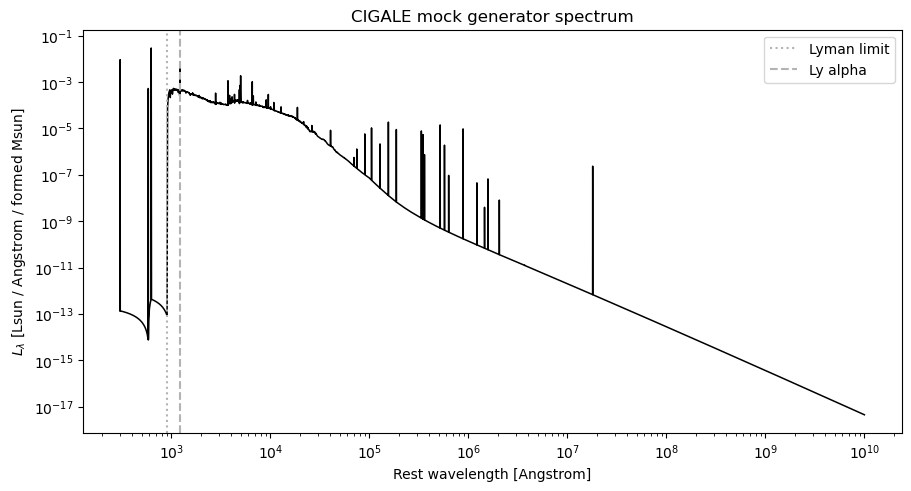

In [5]:
wave_a = mock['rest_wave_a']
lum = mock['rest_luminosity_lsun_per_a']
good = np.isfinite(lum) & (lum > 0)

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
ax.plot(wave_a[good], lum[good], color='black', lw=1.1)
ax.axvline(912.0, color='0.7', ls=':', label='Lyman limit')
ax.axvline(1216.0, color='0.7', ls='--', label='Ly alpha')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Rest wavelength [Angstrom]')
ax.set_ylabel(r'$L_\lambda$ [Lsun / Angstrom / formed Msun]')
ax.set_title('CIGALE mock generator spectrum')
ax.legend()
plt.show()

## Mock photometry

This is the actual flux vector consumed by the photometric likelihood. No masks or upper limits are used in this particular validation run; all ten bands are active detections.

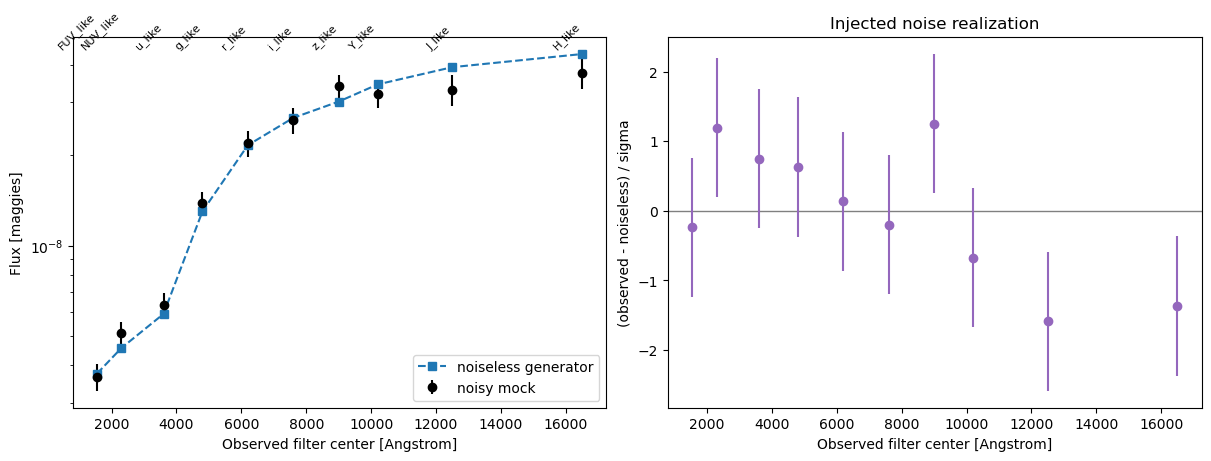

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
ax.errorbar(centers_a, observed, yerr=sigma, fmt='o', color='black', label='noisy mock')
ax.plot(centers_a, noiseless, 's--', color='tab:blue', label='noiseless generator')
for x, name in zip(centers_a, band_names):
    ax.text(x, observed.max() * 1.18, name, rotation=45, ha='right', va='bottom', fontsize=8)
ax.set_yscale('log')
ax.set_xlabel('Observed filter center [Angstrom]')
ax.set_ylabel('Flux [maggies]')
ax.legend()

ax = axes[1]
ax.axhline(0.0, color='0.5', lw=1)
ax.errorbar(centers_a, (observed - noiseless) / sigma, yerr=np.ones_like(sigma), fmt='o', color='tab:purple')
ax.set_xlabel('Observed filter center [Angstrom]')
ax.set_ylabel('(observed - noiseless) / sigma')
ax.set_title('Injected noise realization')
plt.show()

## Load fit results

If the fit file is absent, set `RUN_JAX_FIT = True` above and rerun the stage cell. The default fit is intentionally modest: 150 warmup and 250 posterior samples.

In [7]:
fit = None
summary = None
if FIT_FILE.exists():
    fit = np.load(FIT_FILE, allow_pickle=True)
    if SUMMARY_FILE.exists():
        summary = json.loads(SUMMARY_FILE.read_text())
    print('Loaded fit:', FIT_FILE)
else:
    print('No fit file found yet. Set RUN_JAX_FIT=True to run NUTS from this notebook.')

Loaded fit: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/experimental_cigale_mock_jaxcigale_cue_nuts_sfhfrac_10pct_reported/jaxcigale_cue_nuts_fit.npz


In [8]:
def age_universe_gyr(z, omega_m=0.3075, h=0.6774):
    z = np.asarray(z, dtype=float)
    omega_l = 1.0 - omega_m
    hubble_time_gyr = 9.778 / h
    arg = np.sqrt(omega_l / omega_m) / (1.0 + z) ** 1.5
    return (2.0 / (3.0 * np.sqrt(omega_l))) * np.arcsinh(arg) * hubble_time_gyr


def reported_samples_from_fit(fit):
    names = [str(x) for x in fit['theta_names']]
    samples = np.asarray(fit['samples'], dtype=float)
    truth = np.asarray(fit['true_theta'], dtype=float)
    if 'tage_fraction' not in names:
        return samples, names, truth
    z_idx = names.index('z')
    age_idx = names.index('tage_fraction')
    out = samples.copy()
    out[:, age_idx] = out[:, age_idx] * age_universe_gyr(out[:, z_idx])
    truth_out = truth.copy()
    truth_out[age_idx] = truth_out[age_idx] * age_universe_gyr(truth_out[z_idx])
    names[age_idx] = 'tage_gyr'
    return out, names, truth_out

if fit is not None:
    samples, names, truth = reported_samples_from_fit(fit)
    q = np.quantile(samples, [0.16, 0.5, 0.84], axis=0)
    posterior_table = pd.DataFrame({
        'parameter': names,
        'truth': truth,
        'q16': q[0],
        'median': q[1],
        'q84': q[2],
        'median_minus_truth': q[1] - truth,
    })
    display(posterior_table)
else:
    samples = names = truth = None

,parameter,truth,q16,median,q84,median_minus_truth
0,log10_mass,10.20000,9.304894,9.717488,10.074794,-0.482512
1,z,0.20000,0.077680,0.128608,0.197944,-0.071392
2,logzsol,-0.39794,-1.115857,-0.873050,-0.541948,-0.475110
3,E_BV_young,0.11000,0.101939,0.149599,0.194555,0.039599
4,tau_gyr,2.50000,1.500346,4.111142,6.627156,1.611142
5,tage_gyr,5.00000,2.535547,5.620648,9.383177,0.620648


## NUTS diagnostics

This is where we check whether a pretty posterior was produced by a sick chain. For this diagnostic we care especially about divergence count, mean leapfrog steps, and the adapted step size.

In [9]:
if summary is not None:
    print('NUTS settings')
    print(json.dumps(summary.get('nuts_settings', {}), indent=2))
    print('\nNUTS diagnostics')
    print(json.dumps(summary.get('nuts_diagnostics', {}), indent=2))
    print('\nTiming')
    print(json.dumps(summary.get('timings', {}), indent=2))
else:
    print('No summary JSON loaded.')

NUTS settings
{
  "target_accept_prob": 0.75,
  "max_tree_depth": 8,
  "dense_mass": true
}

NUTS diagnostics
{
  "accept_prob": {
    "mean": 0.7797570707729687,
    "median": 0.8459535439202761,
    "min": 0.12811166444443597,
    "max": 1.0
  },
  "adapt_state.step_size": {
    "mean": 0.03309917049814314,
    "median": 0.033099170498143135,
    "min": 0.033099170498143135,
    "max": 0.033099170498143135
  },
  "diverging": {
    "n_true": 0,
    "fraction_true": 0.0
  },
  "num_steps": {
    "mean": 138.888,
    "median": 127.0,
    "min": 7.0,
    "max": 255.0
  }
}

Timing
{
  "nuts_seconds": 613.3995082080364,
  "posterior_samples": 250,
  "posterior_samples_per_second": 0.40756472193846577
}


## Posterior traces and corner plot

The diagonal shows marginal histograms. Lower panels show pairwise samples. Red lines mark the CIGALE generator truth. The age panel is reported as `tage_gyr`, even though NUTS internally sampled `tage_fraction`.

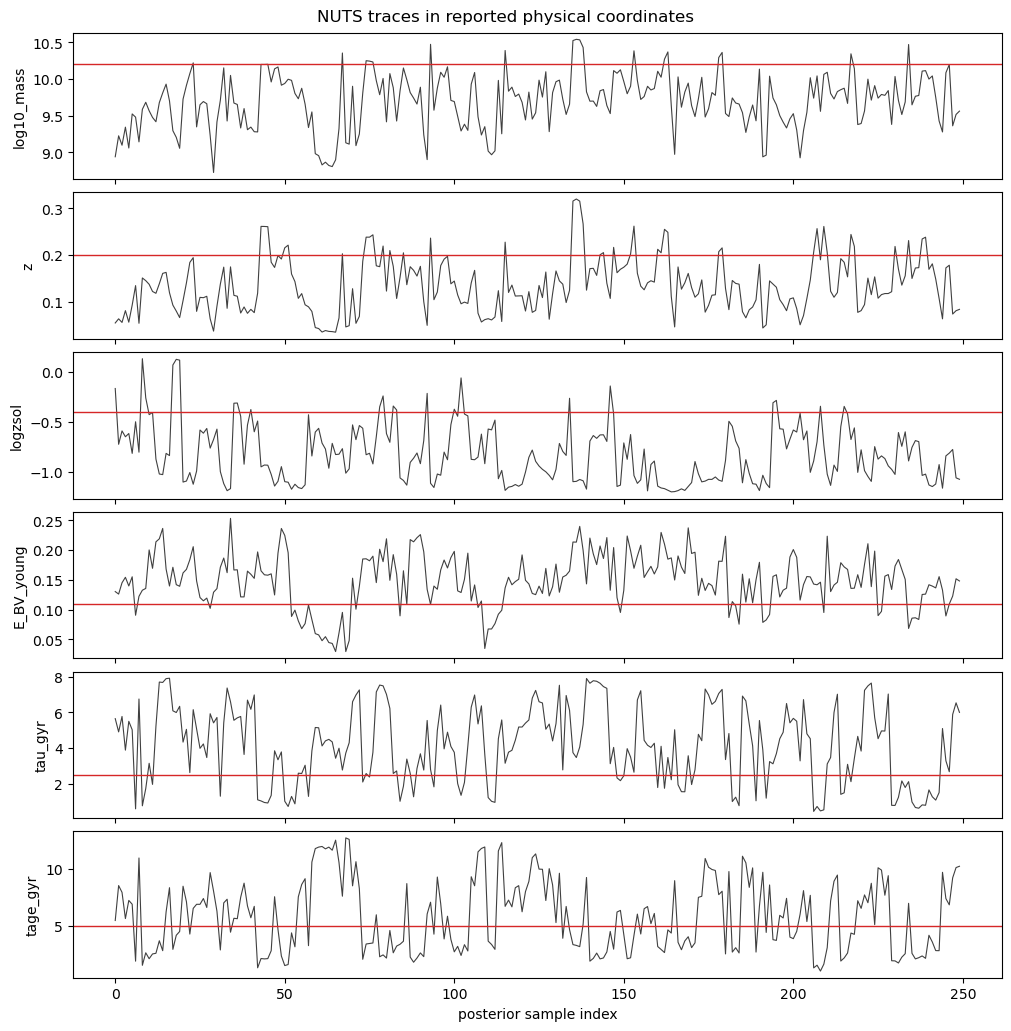

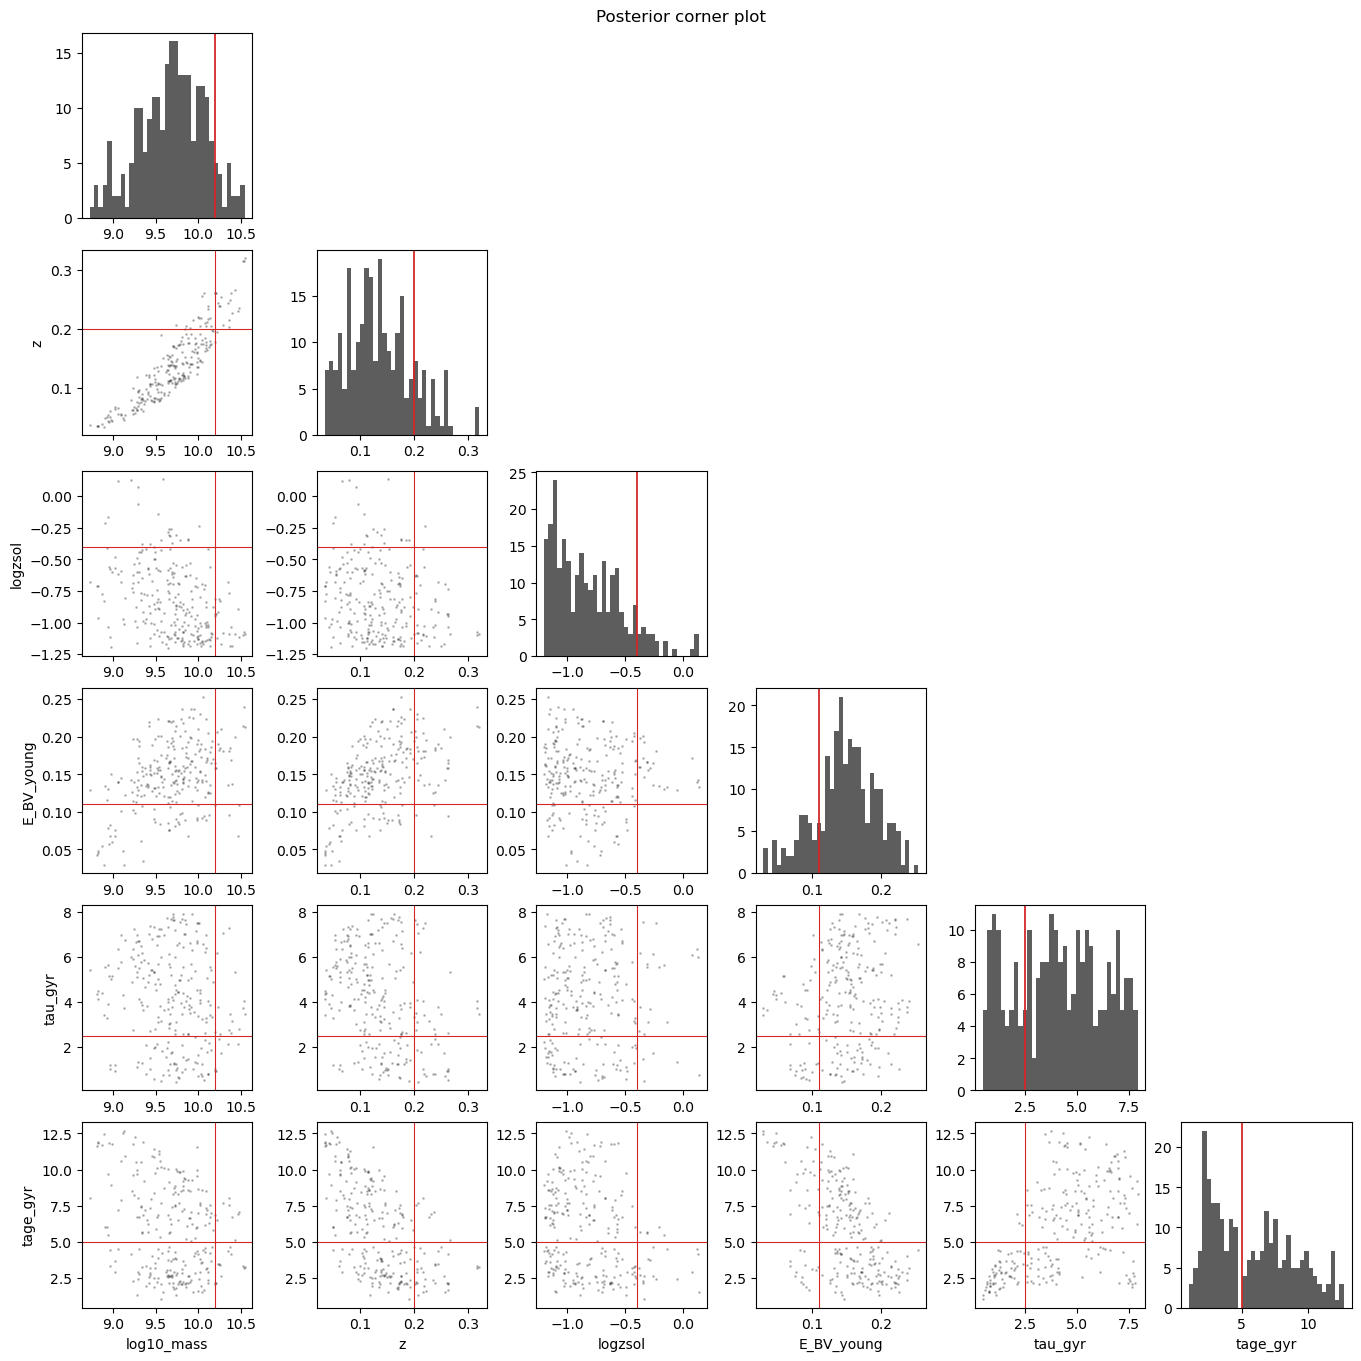

In [10]:
if fit is not None:
    n = len(names)
    fig, axes = plt.subplots(n, 1, figsize=(10, 1.7 * n), sharex=True, constrained_layout=True)
    for i, (ax, name) in enumerate(zip(axes, names)):
        ax.plot(samples[:, i], color='0.25', lw=0.8)
        ax.axhline(truth[i], color='tab:red', lw=1)
        ax.set_ylabel(name)
    axes[-1].set_xlabel('posterior sample index')
    fig.suptitle('NUTS traces in reported physical coordinates')
    plt.show()

    fig, axes = plt.subplots(n, n, figsize=(2.25 * n, 2.25 * n), constrained_layout=True)
    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            if row == col:
                ax.hist(samples[:, col], bins=35, color='0.25', alpha=0.85)
                ax.axvline(truth[col], color='tab:red', lw=1.3)
            elif row > col:
                ax.plot(samples[:, col], samples[:, row], '.', ms=2, alpha=0.25, color='0.15')
                ax.axvline(truth[col], color='tab:red', lw=0.8)
                ax.axhline(truth[row], color='tab:red', lw=0.8)
            else:
                ax.axis('off')
                continue
            if row == n - 1:
                ax.set_xlabel(names[col])
            if col == 0 and row > 0:
                ax.set_ylabel(names[row])
    fig.suptitle('Posterior corner plot')
    plt.show()
else:
    print('No fit loaded.')

## Posterior predictive photometry

This compares the noisy CIGALE mock, the noiseless generator, and JAX-CIGALE posterior predictive fluxes.

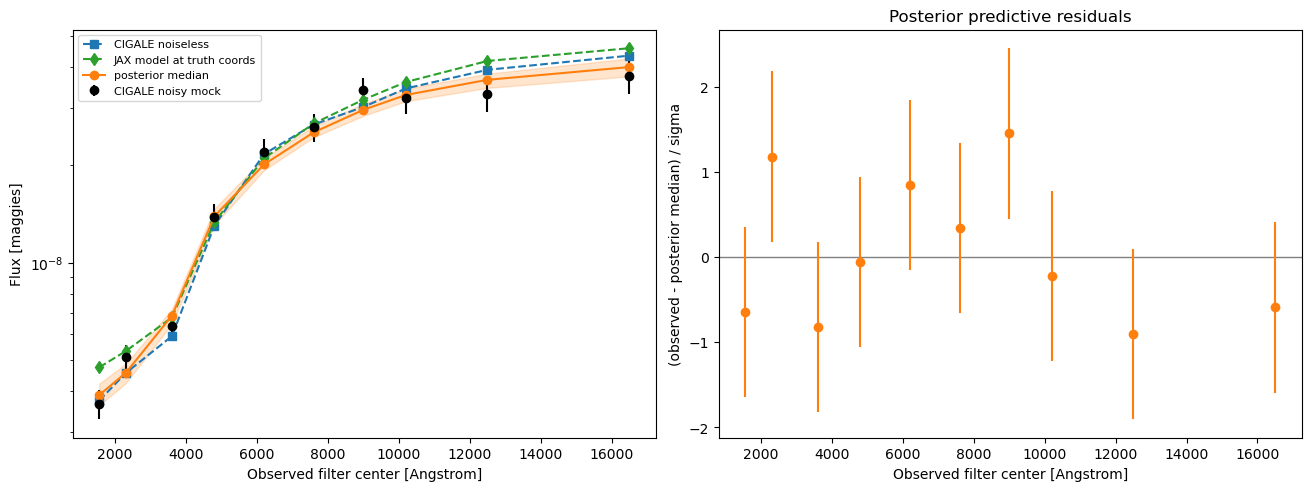

,band,observed_maggies,posterior_median_maggies,residual_sigma,posterior_minus_noiseless_mag
0,FUV_like,3.658771e-09,3.899254e-09,-0.641374,-0.042810
1,NUV_like,5.102824e-09,4.564808e-09,1.179896,-0.001416
2,u_like,6.368567e-09,6.853590e-09,-0.818425,-0.158019
3,g_like,1.382572e-08,1.390432e-08,-0.060425,-0.072378
4,r_like,2.191766e-08,2.008720e-08,0.846544,0.079929
5,i_like,2.613695e-08,2.522739e-08,0.341082,0.060210
6,z_like,3.399226e-08,2.960213e-08,1.453222,0.022021
7,Y_like,3.213898e-08,3.290261e-08,-0.221600,0.050177
8,J_like,3.308890e-08,3.663855e-08,-0.902421,0.077068
9,H_like,3.755137e-08,4.011612e-08,-0.589525,0.088033


In [11]:
if fit is not None:
    median = fit['posterior_flux_median_maggies']
    q16 = fit['posterior_flux_q16_maggies']
    q84 = fit['posterior_flux_q84_maggies']
    truth_model = fit['model_flux_at_truth_maggies']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
    ax = axes[0]
    ax.errorbar(centers_a, observed, yerr=sigma, fmt='o', color='black', label='CIGALE noisy mock')
    ax.plot(centers_a, noiseless, 's--', color='tab:blue', label='CIGALE noiseless')
    ax.plot(centers_a, truth_model, 'd--', color='tab:green', label='JAX model at truth coords')
    ax.plot(centers_a, median, 'o-', color='tab:orange', label='posterior median')
    ax.fill_between(centers_a, q16, q84, color='tab:orange', alpha=0.2)
    ax.set_yscale('log')
    ax.set_xlabel('Observed filter center [Angstrom]')
    ax.set_ylabel('Flux [maggies]')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.axhline(0.0, color='0.5', lw=1)
    ax.errorbar(centers_a, (observed - median) / sigma, yerr=np.ones_like(sigma), fmt='o', color='tab:orange')
    ax.set_xlabel('Observed filter center [Angstrom]')
    ax.set_ylabel('(observed - posterior median) / sigma')
    ax.set_title('Posterior predictive residuals')
    plt.show()

    residual_table = pd.DataFrame({
        'band': band_names,
        'observed_maggies': observed,
        'posterior_median_maggies': median,
        'residual_sigma': (observed - median) / sigma,
        'posterior_minus_noiseless_mag': -2.5 * np.log10(median / noiseless),
    })
    display(residual_table)
else:
    print('No fit loaded.')

## Audit checklist

- Mock fluxes are finite and positive.
- Noise is exactly `0.10 * abs(flux) + floor` in maggies.
- CIGALE spectrum unit conversion is explicit: `W/nm -> Lsun/Angstrom`.
- Mass scaling occurs exactly once, before observed photometry.
- The sampler coordinate is `tage_fraction`; reported output is `tage_gyr`.
- No upper limits are used in this notebook, but the JAX likelihood now supports them through censored Gaussian CDF terms.
- Spectro-photometric likelihood support exists in the JAX layer; the next notebook should use `GaussianSpectralData` or `GaussianSpectroPhotometricData`.